In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Task 3: Unsupervised Symmetry Discovery

## Objective

The goal of this task is to discover symmetries in the latent space that preserve the classifier output (logits). The approach follows the paper:

Oracle-Preserving Latent Flows

The idea is to learn transformations in latent space that change the input representation but keep the classifier prediction unchanged.

## Method

1. Train a latent classifier ψ(z) that predicts the digit class.
2. Learn a generator g(z) that produces a symmetry direction in latent space.
3. Apply the transformation:

z_new = z + ε g(z)

4. Enforce the constraint:

ψ(z) ≈ ψ(z_new)

This ensures that the transformation preserves the classifier output.

## Interpretation

If the learned generator corresponds to rotation, then applying it repeatedly should rotate the decoded image while keeping the digit identity unchanged.

## Experiments

The following analyses are performed:

• latent symmetry vector field  
• symmetry trajectories  
• decoded symmetry flows  
• cycle consistency  
• multiple symmetry generators

These experiments verify that the learned transformation corresponds to rotation symmetry.

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm import tqdm
from torchvision.datasets import MNIST
import torchvision.transforms as transforms
from torchvision.transforms import functional as TF
from torch.utils.data import DataLoader, TensorDataset
from sklearn.decomposition import PCA
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [3]:
transform = transforms.ToTensor()

mnist = MNIST(root="./data", train=True, download=True, transform=transform)

images = []
labels = []

for img, label in mnist:
    if label in [1,2]:
        images.append(img)
        labels.append(label)

images = torch.stack(images)
labels = torch.tensor(labels)
angles = list(range(0,360,30))
rotated_images = []
rotation_labels = []

for img in images:
    for angle in angles:
        rotated = TF.rotate(img, angle)
        rotated_images.append(rotated)
        rotation_labels.append(angle)

rotated_images = torch.stack(rotated_images)
rotation_labels = torch.tensor(rotation_labels)

print(rotated_images.shape)

100%|██████████| 9.91M/9.91M [00:00<00:00, 39.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.13MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.3MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.80MB/s]


torch.Size([152400, 1, 28, 28])


In [4]:
latent_dim = 32

class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1,32,4,stride=2,padding=1),
            nn.ReLU(),
            nn.Conv2d(32,64,4,stride=2,padding=1),
            nn.ReLU()
        )
        self.fc_mu = nn.Linear(64*7*7,latent_dim)
        self.fc_logvar = nn.Linear(64*7*7,latent_dim)

    def forward(self,x):
        x = self.conv(x)
        x = x.view(x.size(0),-1)
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu,logvar


class Decoder(nn.Module):

    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(latent_dim,64*7*7)
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(64,32,4,stride=2,padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32,1,4,stride=2,padding=1),
            nn.Sigmoid()
        )

    def forward(self,z):
        x = self.fc(z)
        x = x.view(-1,64,7,7)
        return self.deconv(x)


class VAE(nn.Module):

    def __init__(self):
        super().__init__()
        self.encoder = Encoder()
        self.decoder = Decoder()

    def reparameterize(self,mu,logvar):
        std = torch.exp(0.5*logvar)
        eps = torch.randn_like(std)
        return mu + eps*std

In [5]:
img_dataset = TensorDataset(rotated_images)
img_loader = DataLoader(img_dataset,batch_size=256,shuffle=True)

vae = VAE().to(device)

optimizer = optim.Adam(vae.parameters(),lr=1e-3)

def vae_loss(recon,x,mu,logvar):
    recon_loss = F.binary_cross_entropy(recon,x,reduction="sum")
    kl = -0.5*torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    )
    return recon_loss + kl


epochs = 20
for epoch in range(epochs):
    total_loss = 0

    for (batch,) in img_loader:
        batch = batch.to(device)
        mu,logvar = vae.encoder(batch)
        z = vae.reparameterize(mu,logvar)
        recon = vae.decoder(z)
        loss = vae_loss(recon,batch,mu,logvar)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print("Epoch",epoch+1,"Loss",total_loss/len(img_loader.dataset))

Epoch 1 Loss 138.47968519956734
Epoch 2 Loss 100.95001493038468
Epoch 3 Loss 97.49948323247314
Epoch 4 Loss 95.85053322939736
Epoch 5 Loss 94.84847510150098
Epoch 6 Loss 94.12839802098712
Epoch 7 Loss 93.53533892293615
Epoch 8 Loss 93.07504395812828
Epoch 9 Loss 92.68691954124631
Epoch 10 Loss 92.31950314499262
Epoch 11 Loss 92.01432543817155
Epoch 12 Loss 91.73702497667527
Epoch 13 Loss 91.48040581490424
Epoch 14 Loss 91.27549586178436
Epoch 15 Loss 91.05835494714772
Epoch 16 Loss 90.84880784402682
Epoch 17 Loss 90.688640940909
Epoch 18 Loss 90.55693056922573
Epoch 19 Loss 90.41022608639375
Epoch 20 Loss 90.29083334294516


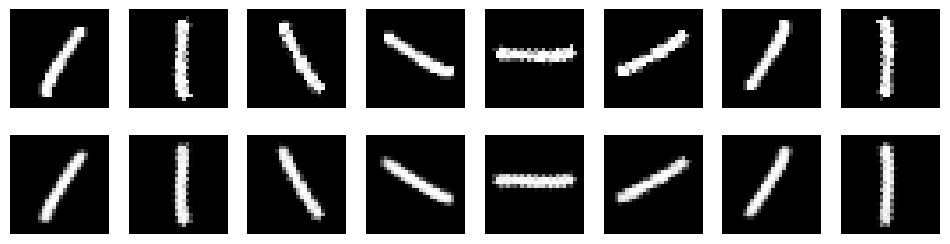

In [6]:
vae.eval()

sample = rotated_images[:8].to(device)

with torch.no_grad():
    mu,_ = vae.encoder(sample)
    recon = vae.decoder(mu)

sample = sample.cpu()
recon = recon.cpu()
fig,ax = plt.subplots(2,8,figsize=(12,3))
for i in range(8):
    ax[0,i].imshow(sample[i].squeeze(),cmap="gray")
    ax[0,i].axis("off")
    ax[1,i].imshow(recon[i].squeeze(),cmap="gray")
    ax[1,i].axis("off")

plt.show()

In [7]:
latent_vectors = []
with torch.no_grad():
    for (batch,) in img_loader:
        batch = batch.to(device)
        mu,_ = vae.encoder(batch)
        latent_vectors.append(mu.cpu())

latent_vectors = torch.cat(latent_vectors)
print(latent_vectors.shape)

torch.Size([152400, 32])


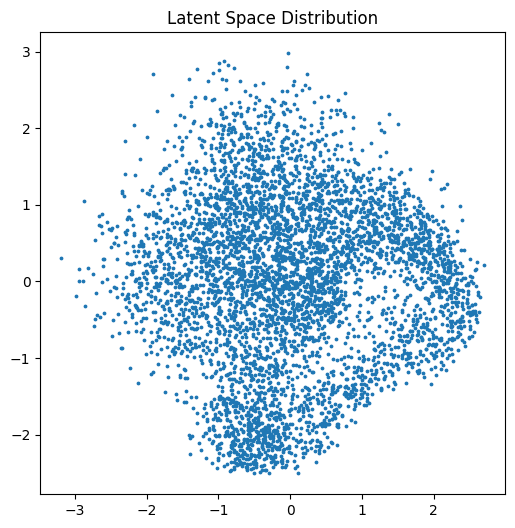

In [8]:
sample_z = latent_vectors[:5000].numpy()
pca = PCA(n_components=2)
z_2d = pca.fit_transform(sample_z)
plt.figure(figsize=(6,6))
plt.scatter(z_2d[:,0],z_2d[:,1],s=3)
plt.title("Latent Space Distribution")
plt.show()

In [9]:
class LatentClassifier(nn.Module):

    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim,128),
            nn.ReLU(),
            nn.Linear(128,128),
            nn.ReLU(),
            nn.Linear(128,2)
        )

    def forward(self,z):
        return self.net(z)


classifier = LatentClassifier().to(device)
optimizer = optim.Adam(classifier.parameters(),lr=1e-3)
criterion = nn.CrossEntropyLoss()
labels_binary = (labels.repeat_interleave(12)-1)
latent_dataset = TensorDataset(latent_vectors,labels_binary)
latent_loader = DataLoader(latent_dataset,batch_size=256,shuffle=True)

for epoch in range(10):
    total_loss = 0

    for z_batch,y_batch in latent_loader:

        z_batch = z_batch.to(device)
        y_batch = y_batch.to(device)
        preds = classifier(z_batch)
        loss = criterion(preds,y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print("Epoch",epoch+1,total_loss/len(latent_loader))

Epoch 1 0.6917659753321002
Epoch 2 0.6910745272500403
Epoch 3 0.690879065618419
Epoch 4 0.6904475013881721
Epoch 5 0.6899066306400619
Epoch 6 0.6891038691837515
Epoch 7 0.6878711517225176
Epoch 8 0.6865304704480524
Epoch 9 0.6848110485596944
Epoch 10 0.6827806545383979


In [10]:
class SymmetryGenerator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim,128),
            nn.ReLU(),
            nn.Linear(128,128),
            nn.ReLU(),
            nn.Linear(128,latent_dim)
        )

    def forward(self,z):
        g = self.net(z)
        g = F.normalize(g,dim=1)
        return g


generator = SymmetryGenerator().to(device)
optimizer = optim.Adam(generator.parameters(),lr=3e-4)
epsilon = 0.02

In [11]:
for epoch in range(30):
    total_loss = 0
    for z_batch,_ in latent_loader:
        z_batch = z_batch.to(device)
        g = generator(z_batch)
        z_new = z_batch + epsilon*g
        logits_old = classifier(z_batch)
        logits_new = classifier(z_new)
        inv_loss = F.mse_loss(logits_old,logits_new)
        norm_loss = ((torch.norm(g,dim=1)-1)**2).mean()
        loss = inv_loss + 0.1*norm_loss
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print("Epoch",epoch+1,total_loss/len(latent_loader))

Epoch 1 2.2602976698965754e-07
Epoch 2 1.247284414096569e-07
Epoch 3 1.0609495635494964e-07
Epoch 4 9.613479377508644e-08
Epoch 5 8.975462899976545e-08
Epoch 6 8.51703310890583e-08
Epoch 7 8.183390652960924e-08
Epoch 8 7.908727790484646e-08
Epoch 9 7.683553126186105e-08
Epoch 10 7.492680435229855e-08
Epoch 11 7.338374874209139e-08
Epoch 12 7.193889212295562e-08
Epoch 13 7.06797539690349e-08
Epoch 14 6.953208291017615e-08
Epoch 15 6.851186100173042e-08
Epoch 16 6.751394738123837e-08
Epoch 17 6.662053646403062e-08
Epoch 18 6.585713533350268e-08
Epoch 19 6.508583575150693e-08
Epoch 20 6.430044791918346e-08
Epoch 21 6.358189627594134e-08
Epoch 22 6.295658966259198e-08
Epoch 23 6.23720507963626e-08
Epoch 24 6.175178118589364e-08
Epoch 25 6.127245742549419e-08
Epoch 26 6.067455415050544e-08
Epoch 27 6.02174861741971e-08
Epoch 28 5.971588134940666e-08
Epoch 29 5.9323526517710134e-08
Epoch 30 5.8815471490876824e-08


In [12]:
with torch.no_grad():
    z = latent_vectors[:1000].to(device)
    g = generator(z)
    z_new = z + epsilon*g
    logits_old = classifier(z)
    logits_new = classifier(z_new)
    diff = torch.mean((logits_old-logits_new)**2)

print("Logit invariance error:",diff.item())

Logit invariance error: 5.73291494276873e-08


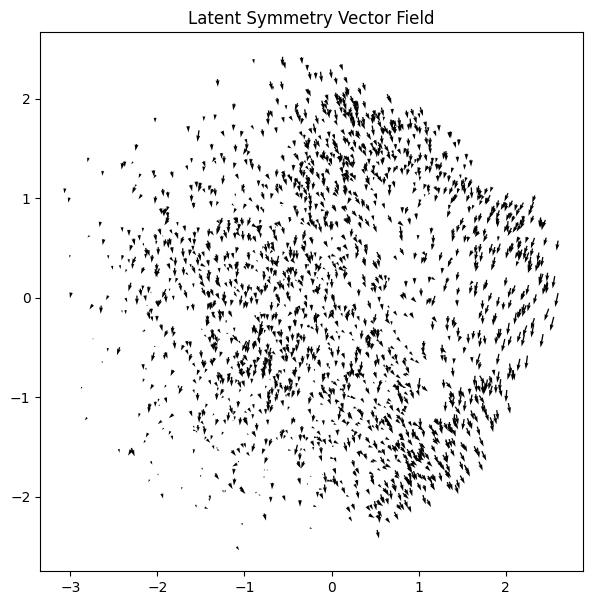

In [13]:
sample_z = latent_vectors[:2000].numpy()
pca = PCA(n_components=2)
z_2d = pca.fit_transform(sample_z)
with torch.no_grad():
    g = generator(
        torch.tensor(sample_z).float().to(device)
    ).cpu().numpy()
    
z_next = sample_z + epsilon*g
z_next_2d = pca.transform(z_next)
dx = z_next_2d[:,0]-z_2d[:,0]
dy = z_next_2d[:,1]-z_2d[:,1]
plt.figure(figsize=(7,7))
plt.quiver(z_2d[:,0],z_2d[:,1],dx,dy)
plt.title("Latent Symmetry Vector Field")
plt.show()

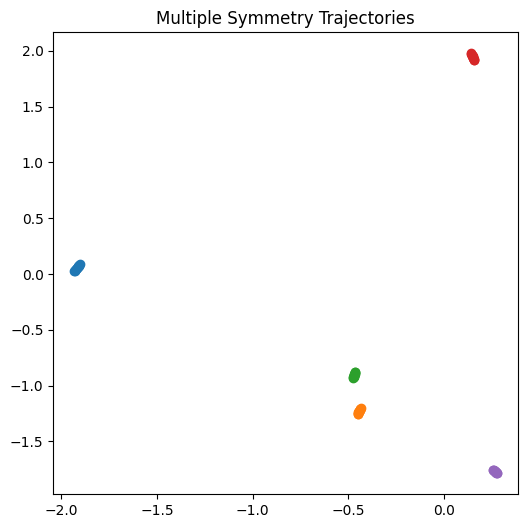

In [14]:
plt.figure(figsize=(6,6))

for i in range(5):
    z = latent_vectors[i*12].unsqueeze(0).to(device)
    traj = []
    for _ in range(12):
        traj.append(z.cpu().numpy()[0])
        with torch.no_grad():
            z = z + epsilon*generator(z)
            
    traj = np.array(traj)
    traj_pca = pca.transform(traj)
    plt.plot(traj_pca[:,0],traj_pca[:,1],marker='o')

plt.title("Multiple Symmetry Trajectories")
plt.show()

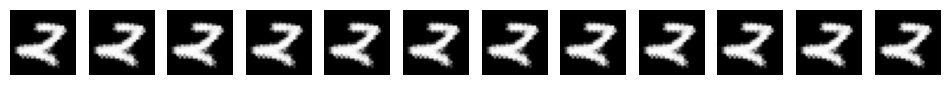

In [15]:
sequence = []
z = latent_vectors[0].unsqueeze(0).to(device)

for i in range(12):
    with torch.no_grad():
        recon = vae.decoder(z)
    sequence.append(recon.cpu())
    z = z + epsilon*generator(z)
    
plt.figure(figsize=(12,2))

for i in range(12):
    plt.subplot(1,12,i+1)
    plt.imshow(sequence[i][0,0],cmap="gray")
    plt.axis("off")
plt.show()

In [16]:
z = latent_vectors[0].unsqueeze(0).to(device)
z_start = z.clone()
for _ in range(12):
    z = z + epsilon*generator(z)
cycle_error = torch.norm(z - z_start)
print("Cycle consistency error:",cycle_error.item())

Cycle consistency error: 0.23999623954296112


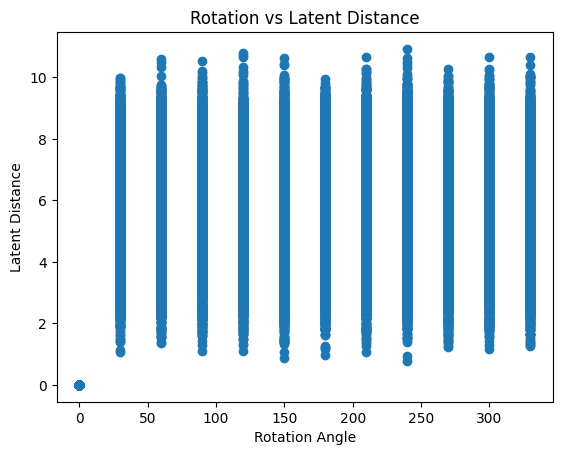

In [17]:
# Rotation vs latent displacement

distances = []
for i in range(0,len(latent_vectors),12):
    group = latent_vectors[i:i+12]
    base = group[0]
    for j in range(12):
        dist = torch.norm(group[j]-base).item()
        angle = j*30
        distances.append((angle,dist))

angles_list = [x[0] for x in distances]
dists = [x[1] for x in distances]
plt.scatter(angles_list,dists)
plt.xlabel("Rotation Angle")
plt.ylabel("Latent Distance")
plt.title("Rotation vs Latent Distance")
plt.show()

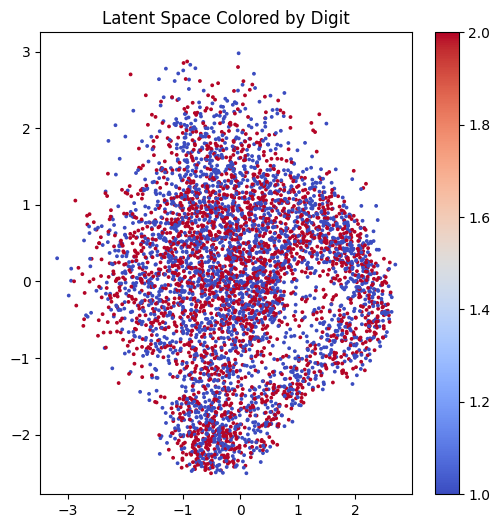

In [19]:
sample_z = latent_vectors[:5000].numpy()
sample_labels = labels.repeat_interleave(12)[:5000]
pca = PCA(n_components=2)
z_2d = pca.fit_transform(sample_z)
plt.figure(figsize=(6,6))
plt.scatter(
    z_2d[:,0],
    z_2d[:,1],
    c=sample_labels,
    cmap="coolwarm",
    s=3
)
plt.colorbar()
plt.title("Latent Space Colored by Digit")
plt.show()

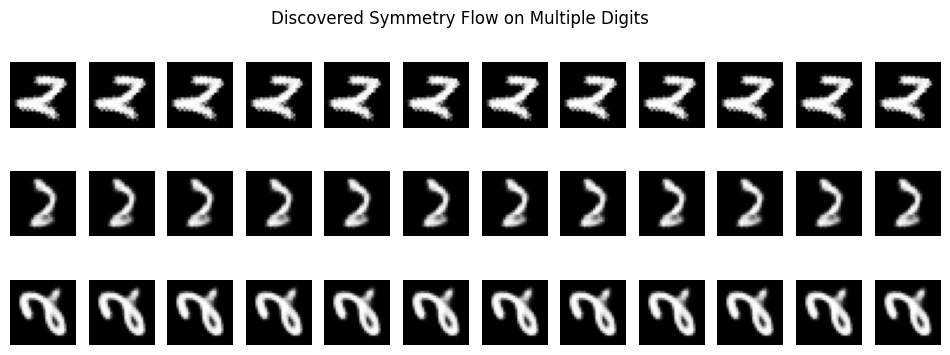

In [20]:
plt.figure(figsize=(12,4))
for i in range(3):
    z = latent_vectors[i*12].unsqueeze(0).to(device)
    sequence = []
    for _ in range(12):
        with torch.no_grad():
            recon = vae.decoder(z)

        sequence.append(recon.cpu())
        z = z + epsilon*generator(z)

    for j in range(12):
        plt.subplot(3,12,i*12+j+1)
        plt.imshow(sequence[j][0,0],cmap="gray")
        plt.axis("off")

plt.suptitle("Discovered Symmetry Flow on Multiple Digits")
plt.show()

In [21]:
class MultiSymmetryGenerator(nn.Module):
    def __init__(self, latent_dim, k=3):
        super().__init__()
        self.latent_dim = latent_dim
        self.k = k
        self.net = nn.Sequential(
            nn.Linear(latent_dim,128),
            nn.ReLU(),
            nn.Linear(128,128),
            nn.ReLU(),
            nn.Linear(128,k*latent_dim)
        )

    def forward(self,z):
        g = self.net(z)
        g = g.view(-1,self.k,self.latent_dim)
        g = F.normalize(g,dim=2)

        return g

In [22]:
num_generators = 3

multi_generator = MultiSymmetryGenerator(
    latent_dim,
    num_generators
).to(device)

optimizer = torch.optim.Adam(
    multi_generator.parameters(),
    lr=3e-4
)

epsilon = 0.02

In [23]:
epochs = 30

for epoch in range(epochs):
    total_loss = 0
    for z_batch,_ in latent_loader:
        z_batch = z_batch.to(device)
        g = multi_generator(z_batch)
        invariance_loss = 0
        for i in range(num_generators):
            z_new = z_batch + epsilon*g[:,i,:]
            logits_old = classifier(z_batch)
            logits_new = classifier(z_new)
            invariance_loss += F.mse_loss(
                logits_old,
                logits_new
            )

        invariance_loss /= num_generators
        norm_loss = ((torch.norm(g,dim=2)-1)**2).mean()
        ortho_loss = 0
        for i in range(num_generators):
            for j in range(i+1,num_generators):
                dot = torch.sum(
                    g[:,i,:]*g[:,j,:],
                    dim=1
                )
                ortho_loss += torch.mean(dot**2)

        loss = invariance_loss + 0.1*norm_loss + 0.1*ortho_loss
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(
        "Epoch",
        epoch+1,
        "Loss",
        total_loss/len(latent_loader)
    )

Epoch 1 Loss 0.00018345674722860356
Epoch 2 Loss 8.18191779827558e-06
Epoch 3 Loss 3.960664620636397e-06
Epoch 4 Loss 2.731803478670659e-06
Epoch 5 Loss 2.174831908728906e-06
Epoch 6 Loss 1.871548289004475e-06
Epoch 7 Loss 1.6727153363247654e-06
Epoch 8 Loss 1.5329039801321988e-06
Epoch 9 Loss 1.407647464696573e-06
Epoch 10 Loss 1.306856373715365e-06
Epoch 11 Loss 1.209943753170842e-06
Epoch 12 Loss 1.1209679422906917e-06
Epoch 13 Loss 1.0322455422330688e-06
Epoch 14 Loss 9.661711605444327e-07
Epoch 15 Loss 8.893329427276409e-07
Epoch 16 Loss 8.180103140416851e-07
Epoch 17 Loss 7.68312758619509e-07
Epoch 18 Loss 7.10146079903543e-07
Epoch 19 Loss 6.690246378668125e-07
Epoch 20 Loss 6.282048243687826e-07
Epoch 21 Loss 5.908578261171641e-07
Epoch 22 Loss 5.66687695450677e-07
Epoch 23 Loss 5.422025249182579e-07
Epoch 24 Loss 5.25813785711365e-07
Epoch 25 Loss 5.041080606014591e-07
Epoch 26 Loss 4.881385300683062e-07
Epoch 27 Loss 4.7681401983196557e-07
Epoch 28 Loss 4.6410648909064524e-07

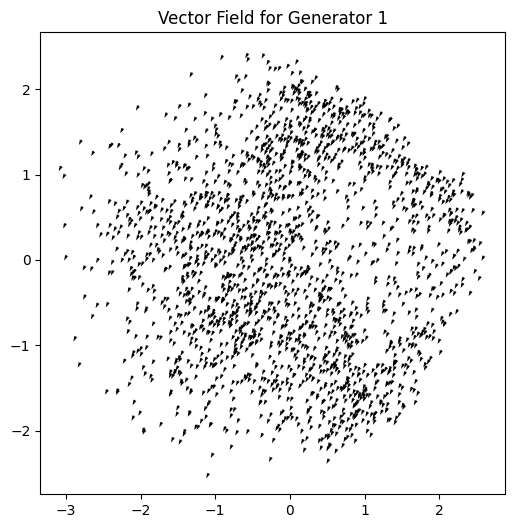

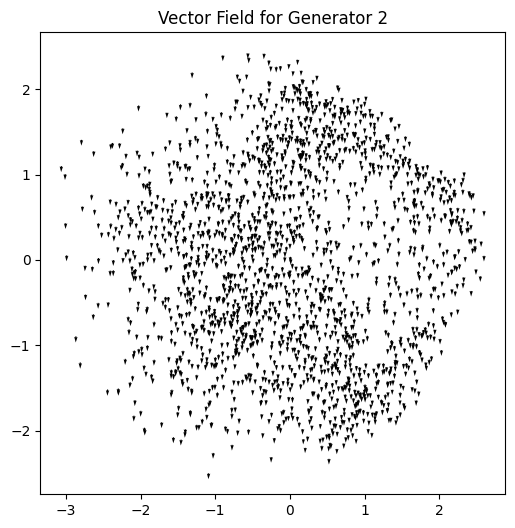

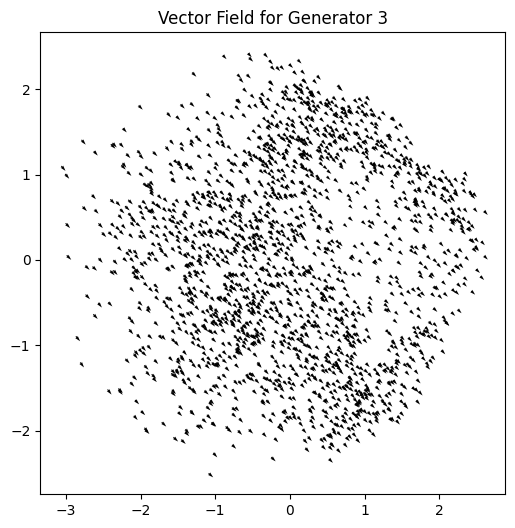

In [24]:
sample_z = latent_vectors[:2000].numpy()
pca = PCA(n_components=2)
z_2d = pca.fit_transform(sample_z)

with torch.no_grad():

    g = multi_generator(
        torch.tensor(sample_z).float().to(device)
    ).cpu().numpy()

for gen_id in range(num_generators):
    g_i = g[:,gen_id,:]
    z_next = sample_z + epsilon*g_i
    z_next_2d = pca.transform(z_next)
    dx = z_next_2d[:,0]-z_2d[:,0]
    dy = z_next_2d[:,1]-z_2d[:,1]

    plt.figure(figsize=(6,6))

    plt.quiver(
        z_2d[:,0],
        z_2d[:,1],
        dx,
        dy
    )

    plt.title(
        f"Vector Field for Generator {gen_id+1}"
    )

    plt.show()

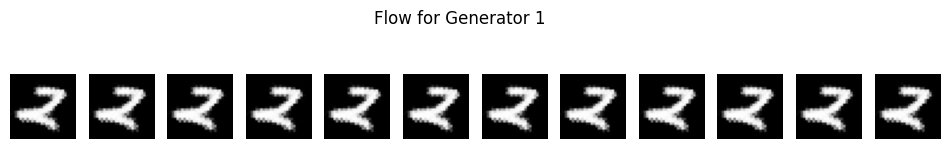

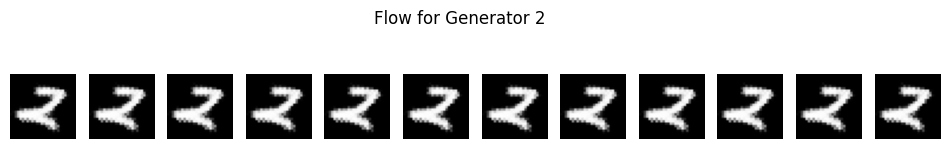

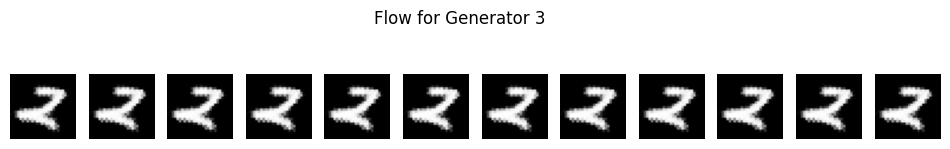

In [25]:
for gen_id in range(num_generators):
    z = latent_vectors[0].unsqueeze(0).to(device)
    sequence = []
    for _ in range(12):
        with torch.no_grad():
            recon = vae.decoder(z)

        sequence.append(recon.cpu())
        g = multi_generator(z)
        z = z + epsilon*g[:,gen_id,:]

    plt.figure(figsize=(12,2))

    for i in range(12):
        plt.subplot(1,12,i+1)
        plt.imshow(
            sequence[i][0,0],
            cmap="gray"
        )
        plt.axis("off")

    plt.suptitle(
        f"Flow for Generator {gen_id+1}"
    )

    plt.show()

In [26]:
with torch.no_grad():

    z = latent_vectors[:1000].to(device)
    g = multi_generator(z)

    for i in range(num_generators):

        z_new = z + epsilon*g[:,i,:]
        logits_old = classifier(z)
        logits_new = classifier(z_new)
        diff = torch.mean(
            (logits_old-logits_new)**2
        )

        print(
            f"Generator {i+1} invariance error:",
            diff.item()
        )

Generator 1 invariance error: 3.869684519486327e-07
Generator 2 invariance error: 4.132694471081777e-07
Generator 3 invariance error: 3.7796971241732535e-07


In [27]:
torch.save(
    vae.state_dict(),
    "vae_task3_model.pth"
)
torch.save(
    generator.state_dict(),
    "symmetry_generator.pth"
)
torch.save(
    multi_generator.state_dict(),
    "multi_symmetry_generator.pth"
)
torch.save(
    classifier.state_dict(),
    "latent_classifier.pth"
)
torch.save(latent_vectors, "latent_vectors.pt")
torch.save(labels_binary, "latent_labels.pt")